In [3]:
import random
import numpy as np
import matplotlib.pyplot as plt

import torch
from torch.utils.data import DataLoader, Subset
from torchvision.datasets import EuroSAT
from torchvision import transforms

from sklearn.model_selection import train_test_split
from collections import Counter

In [4]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: NVIDIA GeForce RTX 4050 Laptop GPU


In [5]:
dataset = EuroSAT(
    root="../data/raw",
    download=True
)

print("Total number of images:", len(dataset))
print("Classes:", dataset.classes)
print("Number of classes:", len(dataset.classes))

Total number of images: 27000
Classes: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']
Number of classes: 10


Image type: <class 'PIL.Image.Image'>
Image size: (64, 64)
Label index: 0
Class: AnnualCrop


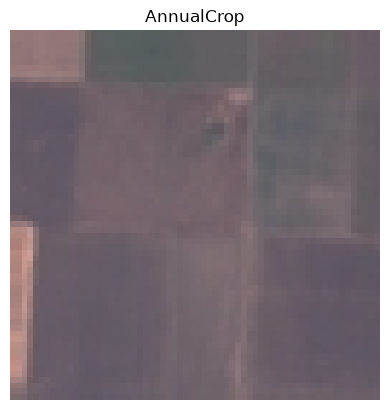

In [6]:
image, label = dataset[0]

print("Image type:", type(image))
print("Image size:", image.size)
print("Label index:", label)
print("Class:", dataset.classes[label])

plt.imshow(image)
plt.title(dataset.classes[label])
plt.axis("off")
plt.show()

In [7]:
labels = np.array([
    dataset[i][1]
    for i in range(len(dataset))
])

print("Number of labels:", len(labels))
print("Unique labels:", np.unique(labels))

Number of labels: 27000
Unique labels: [0 1 2 3 4 5 6 7 8 9]


In [8]:
class_counts = Counter(labels)

for class_idx, count in sorted(class_counts.items()):
    print(f"{dataset.classes[class_idx]:25s}: {count}")

AnnualCrop               : 3000
Forest                   : 3000
HerbaceousVegetation     : 3000
Highway                  : 2500
Industrial               : 2500
Pasture                  : 2000
PermanentCrop            : 2500
Residential              : 3000
River                    : 2500
SeaLake                  : 3000


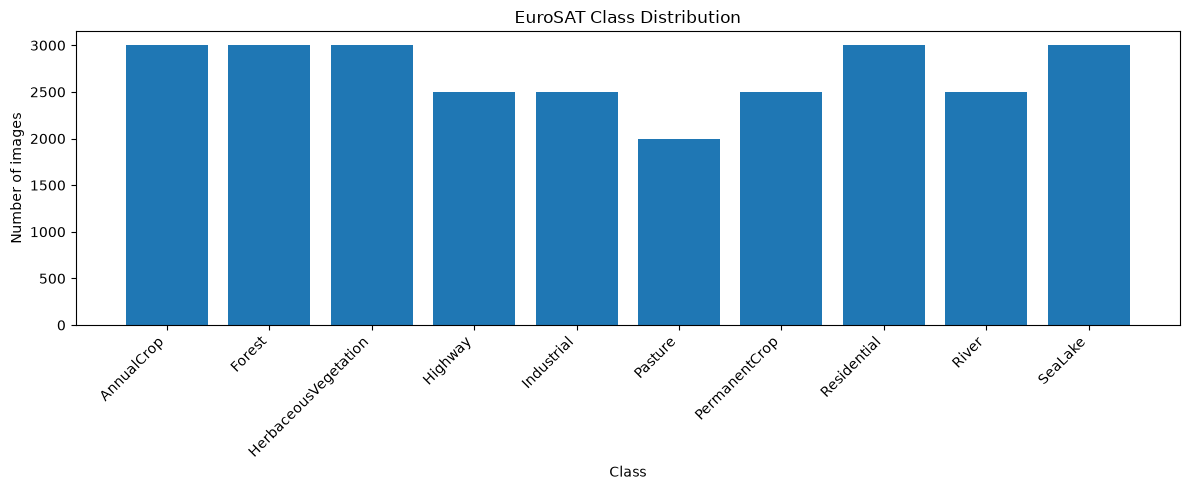

In [9]:
class_names = dataset.classes
counts = [class_counts[i] for i in range(len(class_names))]

plt.figure(figsize=(12, 5))
plt.bar(class_names, counts)
plt.xticks(rotation=45, ha="right")
plt.xlabel("Class")
plt.ylabel("Number of images")
plt.title("EuroSAT Class Distribution")
plt.tight_layout()
plt.show()

In [10]:
indices = np.arange(len(dataset))

train_indices, temp_indices = train_test_split(
    indices,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)


In [11]:
temp_labels = labels[temp_indices]

val_indices, test_indices = train_test_split(
    temp_indices,
    test_size=0.50,
    random_state=SEED,
    stratify=temp_labels
)


In [12]:
print("Train:", len(train_indices))
print("Validation:", len(val_indices))
print("Test:", len(test_indices))
print("Total:", len(train_indices) + len(val_indices) + len(test_indices))

Train: 18900
Validation: 4050
Test: 4050
Total: 27000


In [13]:
train_set_ids = set(train_indices)
val_set_ids = set(val_indices)
test_set_ids = set(test_indices)

print("Train ∩ Validation:", len(train_set_ids & val_set_ids))
print("Train ∩ Test:", len(train_set_ids & test_set_ids))
print("Validation ∩ Test:", len(val_set_ids & test_set_ids))

Train ∩ Validation: 0
Train ∩ Test: 0
Validation ∩ Test: 0


In [14]:
assert len(train_set_ids & val_set_ids) == 0
assert len(train_set_ids & test_set_ids) == 0
assert len(val_set_ids & test_set_ids) == 0

assert len(train_indices) + len(val_indices) + len(test_indices) == len(dataset)

print("Split verification passed.")

Split verification passed.


In [15]:
def print_split_distribution(name, indices):
    split_labels = labels[indices]
    counts = Counter(split_labels)

    print(f"\n{name}")

    for class_idx, count in sorted(counts.items()):
        percentage = count / len(indices) * 100
        print(
            f"{class_names[class_idx]:25s}: "
            f"{count:4d} ({percentage:.2f}%)"
        )

In [16]:
print_split_distribution("Training", train_indices)
print_split_distribution("Validation", val_indices)
print_split_distribution("Testing", test_indices)


Training
AnnualCrop               : 2100 (11.11%)
Forest                   : 2100 (11.11%)
HerbaceousVegetation     : 2100 (11.11%)
Highway                  : 1750 (9.26%)
Industrial               : 1750 (9.26%)
Pasture                  : 1400 (7.41%)
PermanentCrop            : 1750 (9.26%)
Residential              : 2100 (11.11%)
River                    : 1750 (9.26%)
SeaLake                  : 2100 (11.11%)

Validation
AnnualCrop               :  450 (11.11%)
Forest                   :  450 (11.11%)
HerbaceousVegetation     :  450 (11.11%)
Highway                  :  375 (9.26%)
Industrial               :  375 (9.26%)
Pasture                  :  300 (7.41%)
PermanentCrop            :  375 (9.26%)
Residential              :  450 (11.11%)
River                    :  375 (9.26%)
SeaLake                  :  450 (11.11%)

Testing
AnnualCrop               :  450 (11.11%)
Forest                   :  450 (11.11%)
HerbaceousVegetation     :  450 (11.11%)
Highway                  :  375 (9.2

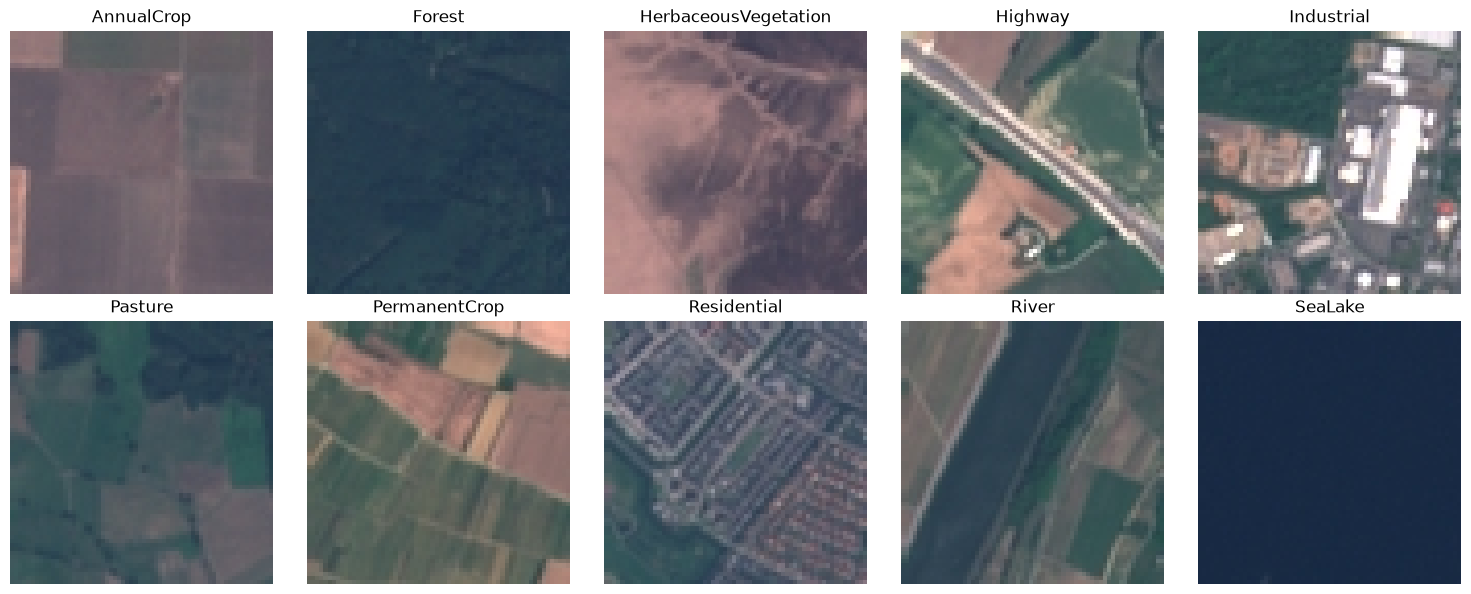

In [17]:
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

for class_idx, ax in enumerate(axes.flat):
    example_idx = np.where(labels == class_idx)[0][0]
    image, _ = dataset[example_idx]

    ax.imshow(image)
    ax.set_title(class_names[class_idx])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Dataset Normalization

Normalization statistics are calculated using only the training subset to avoid using information from the validation or test sets during preprocessing.

In [18]:
from torch.utils.data import Dataset

class TransformSubset(Dataset):
    def __init__(self, dataset, indices, transform=None):
        self.dataset = dataset
        self.indices = np.array(indices)
        self.transform = transform

    def __len__(self):
        return len(self.indices)

    def __getitem__(self, idx):
        image, label = self.dataset[int(self.indices[idx])]

        if self.transform is not None:
            image = self.transform(image)

        return image, label

In [19]:
tensor_transform = transforms.ToTensor()

train_tensor_dataset = TransformSubset(
    dataset,
    train_indices,
    transform=tensor_transform
)

In [20]:
stats_loader = DataLoader(
    train_tensor_dataset,
    batch_size=128,
    shuffle=False,
    num_workers=0
)

channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
num_pixels = 0

for images, _ in stats_loader:
    channel_sum += images.sum(dim=[0, 2, 3])
    channel_squared_sum += (images ** 2).sum(dim=[0, 2, 3])

    num_pixels += images.size(0) * images.size(2) * images.size(3)

mean = channel_sum / num_pixels
std = torch.sqrt(channel_squared_sum / num_pixels - mean ** 2)

print("Training mean:", mean)
print("Training std :", std)

Training mean: tensor([0.3439, 0.3800, 0.4075])
Training std : tensor([0.2024, 0.1367, 0.1154])


In [21]:
train_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=mean.tolist(), std=std.tolist())
])

In [22]:
train_dataset = TransformSubset(
    dataset,
    train_indices,
    transform=train_transform
)

val_dataset = TransformSubset(
    dataset,
    val_indices,
    transform=eval_transform
)

test_dataset = TransformSubset(
    dataset,
    test_indices,
    transform=eval_transform
)

print("Training samples  :", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples   :", len(test_dataset))

Training samples  : 18900
Validation samples: 4050
Testing samples   : 4050


In [23]:
BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=torch.cuda.is_available()
)

In [24]:
images, labels_batch = next(iter(train_loader))

print("Image batch shape:", images.shape)
print("Label batch shape:", labels_batch.shape)
print("Image dtype:", images.dtype)
print("Label dtype:", labels_batch.dtype)

print("Batch minimum:", images.min().item())
print("Batch maximum:", images.max().item())

Image batch shape: torch.Size([64, 3, 64, 64])
Label batch shape: torch.Size([64])
Image dtype: torch.float32
Label dtype: torch.int64
Batch minimum: -1.689563512802124
Batch maximum: 5.133508205413818


In [25]:
images = images.to(device)
labels_batch = labels_batch.to(device)

print("Images device:", images.device)
print("Labels device:", labels_batch.device)

Images device: cuda:0
Labels device: cuda:0


In [26]:
def denormalize(image, mean, std):
    mean = torch.tensor(mean).view(3, 1, 1)
    std = torch.tensor(std).view(3, 1, 1)

    return image * std + mean

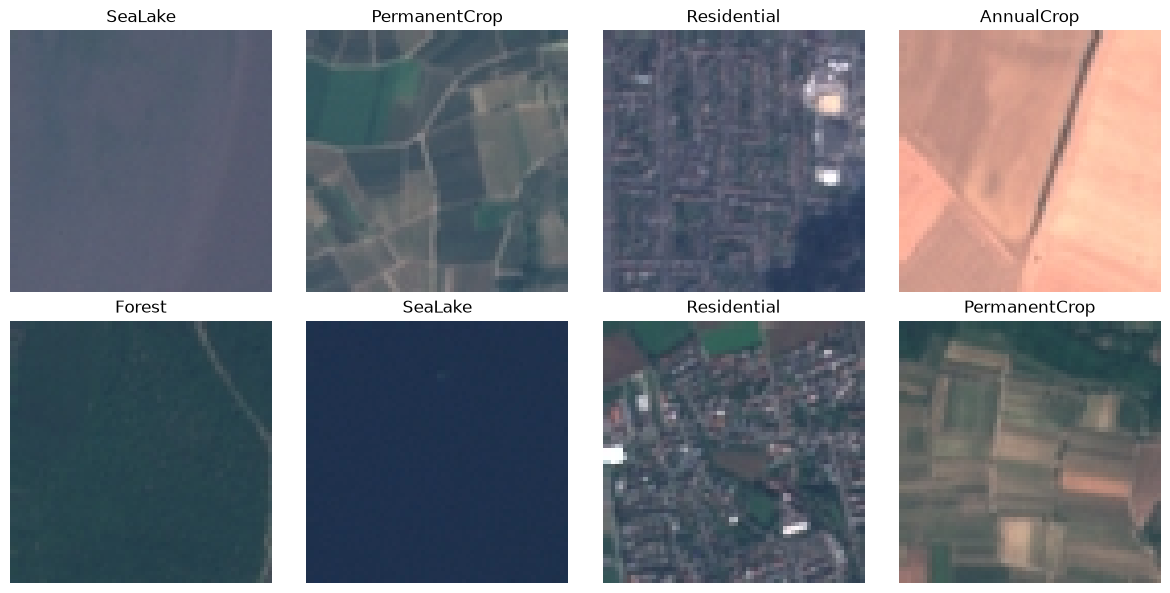

In [27]:
images_cpu, labels_cpu = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    image = denormalize(
        images_cpu[i],
        mean.tolist(),
        std.tolist()
    )

    image = image.clamp(0, 1)
    image = image.permute(1, 2, 0)

    ax.imshow(image)
    ax.set_title(class_names[labels_cpu[i].item()])
    ax.axis("off")

plt.tight_layout()
plt.show()

## Data Preparation Summary

The EuroSAT RGB dataset was prepared for all subsequent experiments using a fixed and reproducible data pipeline.

- Total images: 27,000
- Number of classes: 10
- Image dimensions: 64 × 64 × 3
- Training set: 18,900 images (70%)
- Validation set: 4,050 images (15%)
- Test set: 4,050 images (15%)
- Split method: stratified
- Random seed: 42
- Batch size: 64
- Normalization statistics: calculated using only the training subset

The same dataset split will be retained for all custom CNN, optimizer, and pretrained-model experiments so that their performance can be compared fairly.